# Prepare Dataset 

## Purpose
Prepare the raw VAERS data for downstream modeling and exploratory analysis by filtering to COVID-19 vaccine reports, aggregating records to the case level, engineering structured predictors, and exporting clean analysis-ready datasets.

## Major sections
1. Setup and data loading  
2. COVID-19 subsetting and case-level aggregation  
3. Outcome construction and structured feature engineering  
4. Exploratory data analysis  
5. Rule-based comorbidity indicators  


## 1. Setup and data loading

This section imports the analysis libraries, defines project-relative file paths, loads the raw VAERS source file, and inspects the starting data structure before any filtering or aggregation.

In [ ]:
# ============================================================
# 1.1 SETUP
# ============================================================

import os
import re
import sys
import json
import math
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")

print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)

Python executable: /Users/ariellerothman/Desktop/Sperm Cell Analysis/.venv/bin/python
Python version: 3.12.10
Pandas version: 2.2.3


In [ ]:
# ============================================================
# 1.2 FILE PATHS
# ============================================================

from pathlib import Path

# Project root = the folder that contains this notebook.
# All output paths are resolved relative to it automatically.
HERE   = Path().resolve()
OUTDIR = str(HERE / "Outputs")
os.makedirs(OUTDIR, exist_ok=True)

# -- Raw VAERS data (NOT included in the repo - file is >1 GB) ---------------
# Download from Kaggle: search 'VAERS ADE detection' or see README for the link.
# Option A (recommended): set an environment variable before launching Jupyter:
#   export VAERS_DATA_PATH=/absolute/path/to/COMBINED_DATA_ALL_YEARS.csv
# Option B: edit the fallback path below to match your local location.
DATA_PATH = os.environ.get(
    "VAERS_DATA_PATH",
    str(HERE.parent / "VAERS_data" / "COMBINED_DATA_ALL_YEARS.csv"),
)

print("DATA_PATH:", DATA_PATH)
print("OUTDIR   :", OUTDIR)

DATA_PATH: /Users/ariellerothman/Desktop/VAERS_data/COMBINED_DATA_ALL_YEARS.csv
OUTDIR   : /Users/ariellerothman/Desktop/Capstone/Outputs


In [ ]:
# ============================================================
# 1.3 LOAD RAW DATA
# ============================================================

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print("Raw shape:", df_raw.shape)
print(df_raw.head(3))
print("\nColumns:")
print(df_raw.columns.tolist())

Raw shape: (2132431, 55)
   VAERS_ID    RECVDATE STATE  AGE_YRS  CAGE_YR  CAGE_MO SEX RPT_DATE  \
0    810053  01/01/2020    OH     73.0     73.0      NaN   F      NaN   
1    810053  01/01/2020    OH     73.0     73.0      NaN   F      NaN   
2    855017  01/01/2020    HI     55.0     55.0      NaN   F      NaN   

                                        SYMPTOM_TEXT DIED  ...  \
0  Extreme shivering for approx. 5 hours then fev...  NaN  ...   
1  Extreme shivering for approx. 5 hours then fev...  NaN  ...   
2  Symptoms occurred almost immediately- aching j...  NaN  ...   

  SYMPTOMVERSION5 ORDER_y VAX_TYPE                     VAX_MANU  VAX_LOT  \
0            22.1       2     FLU3               SANOFI PASTEUR      NaN   
1             NaN       2     FLU3               SANOFI PASTEUR      NaN   
2             NaN       1   VARZOS  GLAXOSMITHKLINE BIOLOGICALS      NaN   

  VAX_DOSE_SERIES VAX_ROUTE VAX_SITE  \
0             UNK       NaN      NaN   
1             UNK       NaN     

In [ ]:
# ============================================================
# 1.4 RAW DATA TYPES + MISSINGNESS SNAPSHOT
# ============================================================

print(df_raw.info())

missing_pct_raw = (df_raw.isna().mean() * 100).sort_values(ascending=False)
print("\nTop missingness percentages:")
print(missing_pct_raw.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2132431 entries, 0 to 2132430
Data columns (total 55 columns):
 #   Column           Dtype  
---  ------           -----  
 0   VAERS_ID         int64  
 1   RECVDATE         object 
 2   STATE            object 
 3   AGE_YRS          float64
 4   CAGE_YR          float64
 5   CAGE_MO          float64
 6   SEX              object 
 7   RPT_DATE         object 
 8   SYMPTOM_TEXT     object 
 9   DIED             object 
 10  DATEDIED         object 
 11  L_THREAT         object 
 12  ER_VISIT         object 
 13  HOSPITAL         object 
 14  HOSPDAYS         float64
 15  X_STAY           object 
 16  DISABLE          object 
 17  RECOVD           object 
 18  VAX_DATE         object 
 19  ONSET_DATE       object 
 20  NUMDAYS          float64
 21  LAB_DATA         object 
 22  V_ADMINBY        object 
 23  V_FUNDBY         object 
 24  OTHER_MEDS       object 
 25  CUR_ILL          object 
 26  HISTORY          object 
 27  PRIOR_VAX   

## 2. COVID-19 subsetting and case-level aggregation

This section:
- subsets to `VAX_TYPE == "COVID19"`
- removes exact duplicate rows
- collapses multiple row-level records per `VAERS_ID`
- preserves clinically relevant information using conservative aggregation rules

In [ ]:
# ============================================================
# 2.1 SUBSET TO COVID-19 REPORTS
# ============================================================

df_covid_rows = df_raw.loc[df_raw["VAX_TYPE"] == "COVID19"].copy()

print("COVID row-level shape:", df_covid_rows.shape)
print("Unique VAERS_ID:", df_covid_rows["VAERS_ID"].nunique())
print("Extra rows beyond one-per-ID:", len(df_covid_rows) - df_covid_rows["VAERS_ID"].nunique())

COVID row-level shape: (1702653, 55)
Unique VAERS_ID: 986096
Extra rows beyond one-per-ID: 716557


In [ ]:
# ============================================================
# 2.2 REMOVE EXACT DUPLICATE ROWS
# ============================================================


before = len(df_covid_rows)
df_covid_rows = df_covid_rows.drop_duplicates()
after = len(df_covid_rows)

print("Rows before exact duplicate removal:", before)
print("Rows after exact duplicate removal:", after)
print("Exact duplicates removed:", before - after)

Rows before exact duplicate removal: 1702653
Rows after exact duplicate removal: 1699449
Exact duplicates removed: 3204


In [ ]:
# ============================================================
# 2.3 BASIC TYPE CLEANING BEFORE CASE-LEVEL AGGREGATION
# ============================================================

date_cols = ["RECVDATE", "VAX_DATE", "ONSET_DATE", "DATEDIED"]
for col in date_cols:
    if col in df_covid_rows.columns:
        df_covid_rows[col] = pd.to_datetime(df_covid_rows[col], errors="coerce")

# Binary outcome source columns in VAERS are usually Y/blank
binary_source_cols = [
    "DIED", "L_THREAT", "ER_VISIT", "ER_ED_VISIT",
    "HOSPITAL", "DISABLE", "BIRTH_DEFECT"
]

for col in binary_source_cols:
    if col in df_covid_rows.columns:
        df_covid_rows[col] = df_covid_rows[col].astype(str).str.upper().str.strip()
        df_covid_rows[col] = df_covid_rows[col].replace({"Y": 1, "N": 0, "": np.nan, "NAN": np.nan})
        df_covid_rows[col] = pd.to_numeric(df_covid_rows[col], errors="coerce")

# Numeric columns
numeric_cols = ["AGE_YRS", "HOSPDAYS", "NUMDAYS"]
for col in numeric_cols:
    if col in df_covid_rows.columns:
        df_covid_rows[col] = pd.to_numeric(df_covid_rows[col], errors="coerce")

# Standardize basic categorical text
for col in ["SEX", "STATE", "VAX_TYPE", "VAX_MANU", "VAX_NAME", "VAX_DOSE_SERIES", "VAX_ROUTE", "VAX_SITE"]:
    if col in df_covid_rows.columns:
        df_covid_rows[col] = df_covid_rows[col].astype("string")

In [ ]:
# ============================================================
# 2.4 CASE-LEVEL AGGREGATION
# ============================================================
# Purpose: Collapse multiple rows per VAERS_ID into single case records

text_fields = ["SYMPTOM_TEXT", "LAB_DATA", "OTHER_MEDS", "CUR_ILL", "HISTORY", "PRIOR_VAX", "ALLERGIES"]
list_fields = ["VAX_MANU", "VAX_NAME", "VAX_DOSE_SERIES", "VAX_ROUTE", "VAX_SITE", "VAX_LOT"]

def concat_unique_text(series):
    """Concatenate unique text values from a series, preserving order."""
    vals = [str(x).strip() for x in series.dropna().astype(str) if str(x).strip()]
    vals_unique = list(dict.fromkeys(vals))
    return " | ".join(vals_unique) if vals_unique else np.nan

def unique_list(series):
    """Extract unique non-null values from a series as a deduplicated list."""
    vals = [str(x).strip() for x in series.dropna().astype(str) if str(x).strip()]
    return list(dict.fromkeys(vals))

agg_dict = {}

for col in binary_source_cols:
    if col in df_covid_rows.columns:
        agg_dict[col] = "max"

if "RECVDATE" in df_covid_rows.columns:
    agg_dict["RECVDATE"] = "min"
if "VAX_DATE" in df_covid_rows.columns:
    agg_dict["VAX_DATE"] = "min"
if "ONSET_DATE" in df_covid_rows.columns:
    agg_dict["ONSET_DATE"] = "max"
if "DATEDIED" in df_covid_rows.columns:
    agg_dict["DATEDIED"] = "max"

if "AGE_YRS" in df_covid_rows.columns:
    agg_dict["AGE_YRS"] = "max"
if "HOSPDAYS" in df_covid_rows.columns:
    agg_dict["HOSPDAYS"] = "max"
if "NUMDAYS" in df_covid_rows.columns:
    agg_dict["NUMDAYS"] = "max"

for col in ["SEX", "STATE", "VAX_TYPE"]:
    if col in df_covid_rows.columns:
        agg_dict[col] = lambda s: s.dropna().iloc[0] if s.dropna().shape[0] else np.nan

for col in text_fields:
    if col in df_covid_rows.columns:
        agg_dict[col] = concat_unique_text

for col in list_fields:
    if col in df_covid_rows.columns:
        agg_dict[col] = unique_list

df_case = df_covid_rows.groupby("VAERS_ID", as_index=False).agg(agg_dict)

print("Case-level shape:", df_case.shape)
print(df_case.head(2).T)

Case-level shape: (986096, 31)
                                                                 0  \
VAERS_ID                                                    109128   
DIED                                                           NaN   
L_THREAT                                                       NaN   
ER_VISIT                                                       NaN   
ER_ED_VISIT                                                    NaN   
HOSPITAL                                                       1.0   
DISABLE                                                        NaN   
BIRTH_DEFECT                                                   NaN   
RECVDATE                                       2021-03-18 00:00:00   
VAX_DATE                                       2021-03-05 00:00:00   
ONSET_DATE                                     2021-03-06 00:00:00   
DATEDIED                                                       NaT   
AGE_YRS                                                    

## 3. Outcome construction and structured feature engineering

In [ ]:
# ============================================================
# 3.1 OUTCOME CONSTRUCTION
# ============================================================

severity_components = [
    "DIED", "DISABLE", "L_THREAT", "HOSPITAL", "ER_VISIT", "ER_ED_VISIT", "BIRTH_DEFECT"
]
severity_components = [c for c in severity_components if c in df_case.columns]

for col in severity_components:
    df_case[col] = df_case[col].fillna(0).astype("int8")

df_case["SERIOUS"] = (df_case[severity_components].sum(axis=1) > 0).astype("int8")
df_case["SEVERE"] = df_case["SERIOUS"].copy()

print(df_case[severity_components + ["SERIOUS"]].mean().sort_values(ascending=False))

SERIOUS         0.198506
ER_ED_VISIT     0.120642
HOSPITAL        0.089814
DISABLE         0.019798
DIED            0.019659
L_THREAT        0.016199
BIRTH_DEFECT    0.000647
ER_VISIT        0.000158
dtype: float64


In [ ]:
# ============================================================
# 3.2 STRUCTURED FEATURE ENGINEERING
# ============================================================
# Purpose: Create derived features from raw fields for modeling
# Output: NEW columns like ONSET_INTERVAL, MAX_DOSE, MANU__*, etc.
# ============================================================

# Remove implausible ages
if "AGE_YRS" in df_case.columns:
    df_case.loc[(df_case["AGE_YRS"] < 0) | (df_case["AGE_YRS"] > 110), "AGE_YRS"] = np.nan

# Onset interval: Days between vaccination and symptom onset
# Clinically relevant: Short intervals suggest vaccine-related causality
if "ONSET_DATE" in df_case.columns and "VAX_DATE" in df_case.columns:
    df_case["ONSET_INTERVAL"] = (df_case["ONSET_DATE"] - df_case["VAX_DATE"]).dt.days

# Temporal features: Extract year and month from report receipt date
# Used for: Time-series analysis, controlling for temporal trends
if "RECVDATE" in df_case.columns:
    df_case["YEAR"] = df_case["RECVDATE"].dt.year.astype("Int64")
    df_case["MONTH"] = df_case["RECVDATE"].dt.month.astype("Int64")

# Dose features: Extract and standardize dose information
def dose_features(dose_list):
    """
    Extract structured dose metrics from a list of dose series values.
    
    Args:
        dose_list (list): Dose values (e.g., ["1", "2", "3"] or ["1", "2", "UNK"]).
    
    Returns:
        pd.Series with columns:
            - MAX_DOSE: Highest numeric dose (1, 2, 3, etc.). 
            - DOSE_COUNT: Number of distinct dose types.
            - MULTI_DOSE: Binary flag (1 if 2+ distinct doses observed).
            - UNKNOWN_DOSE: Binary flag (1 if "UNK"/"UNKNOWN" in list).
    
    Logic:
        - "7+" and numeric values normalized to integers for comparison
        - Unknown doses flagged separately (indicates incomplete data)
        - Empty/null lists return [NA, 0, 0, 0]
    
    """
    if not isinstance(dose_list, list) or len(dose_list) == 0:
        return pd.Series([pd.NA, 0, 0, 0], index=["MAX_DOSE","DOSE_COUNT","MULTI_DOSE","UNKNOWN_DOSE"])

    cleaned = []
    unknown = 0
    for d in dose_list:
        if pd.isna(d):
            continue
        d = str(d).strip().upper()
        if d in ("UNK", "UNKNOWN"):
            unknown = 1
            cleaned.append("UNK")
        elif d == "7+":
            cleaned.append("7+")
        else:
            cleaned.append(d)

    # Convert cleaned values to numeric for aggregation
    nums = []
    for d in cleaned:
        if d == "7+":
            nums.append(7)
        else:
            try:
                nums.append(int(d))
            except Exception:
                pass

    max_dose = max(nums) if nums else pd.NA
    dose_count = len(set(cleaned))
    multi_dose = int(dose_count > 1)

    return pd.Series([max_dose, dose_count, multi_dose, unknown], index=["MAX_DOSE","DOSE_COUNT","MULTI_DOSE","UNKNOWN_DOSE"])

if "VAX_DOSE_SERIES" in df_case.columns:
    df_case[["MAX_DOSE","DOSE_COUNT","MULTI_DOSE","UNKNOWN_DOSE"]] = df_case["VAX_DOSE_SERIES"].apply(dose_features)

# Manufacturer multi-hot encoding
# Purpose: Create binary indicators for each vaccine manufacturer observed in case
# Rationale: Multi-manufacturer exposure (booster switching) is clinically meaningful
if "VAX_MANU" in df_case.columns:
    manu_lists = df_case["VAX_MANU"].apply(lambda x: x if isinstance(x, list) else [])
    manufacturers = sorted(set(m for lst in manu_lists for m in lst if pd.notna(m)))
    
    # Create one binary column per manufacturer
    # E.g., MANU__PFIZER=1 if Pfizer was administered, 0 otherwise
    for manu in manufacturers:
        safe = re.sub(r"[^A-Za-z0-9]+", "_", str(manu)).strip("_").upper()
        colname = f"MANU__{safe}"
        df_case[colname] = manu_lists.apply(lambda lst: int(manu in set(lst))).astype("int8")
    
    # Flag cases with multiple manufacturers (e.g., dose 1=Pfizer, dose 2=Moderna)
    df_case["MULTI_MANUFACTURER"] = manu_lists.apply(lambda lst: int(len(set(lst)) > 1)).astype("int8")

print("Manufacturer columns:", [c for c in df_case.columns if c.startswith("MANU__")])
print(df_case[["MAX_DOSE","DOSE_COUNT","MULTI_DOSE","UNKNOWN_DOSE","MULTI_MANUFACTURER"]].head())

Manufacturer columns: ['MANU__JANSSEN', 'MANU__MODERNA', 'MANU__NOVAVAX', 'MANU__PFIZER_BIONTECH', 'MANU__UNKNOWN_MANUFACTURER']
  MAX_DOSE  DOSE_COUNT  MULTI_DOSE  UNKNOWN_DOSE  MULTI_MANUFACTURER
0        1           1           0             0                   0
1        1           1           0             0                   0
2        1           1           0             0                   0
3        1           1           0             0                   0
4        1           1           0             0                   0


## 4. Exploratory data analysis

Case-level dataset shape: (986096, 51)

Serious rate: 0.1985060278106797

Sex distribution:
SEX
F       630052
M       314301
U        41509
<NA>       234
Name: count, dtype: Int64

Age summary:
count    883244.000000
mean         50.006935
std          20.166280
min           0.080000
25%          35.000000
50%          51.000000
75%          66.000000
max         110.000000
Name: AGE_YRS, dtype: float64


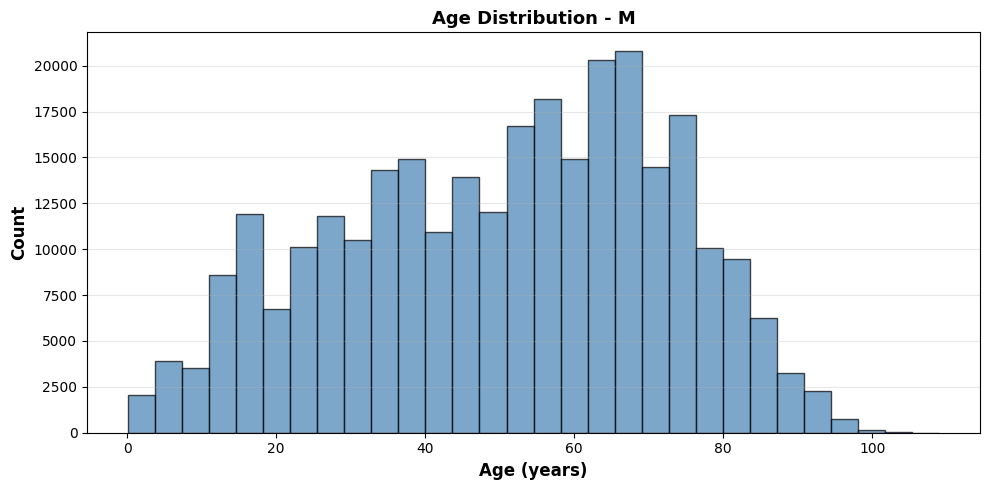

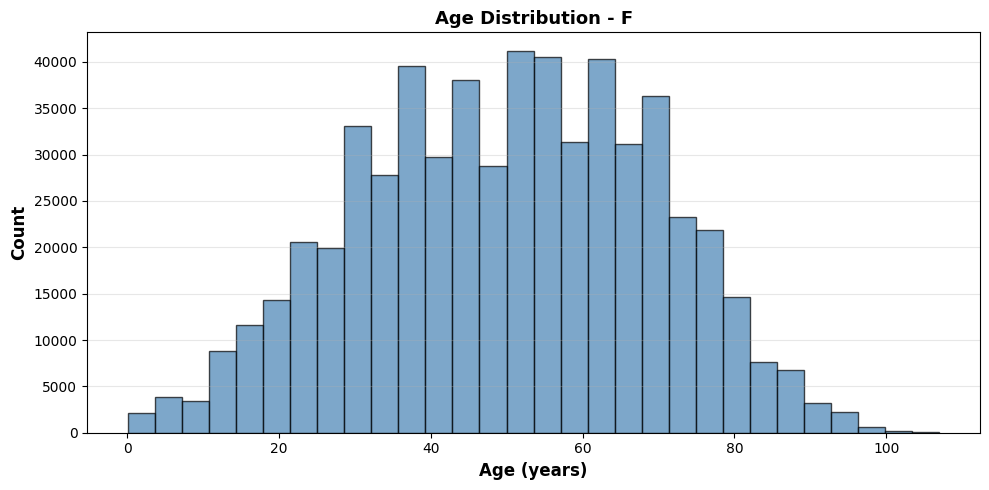

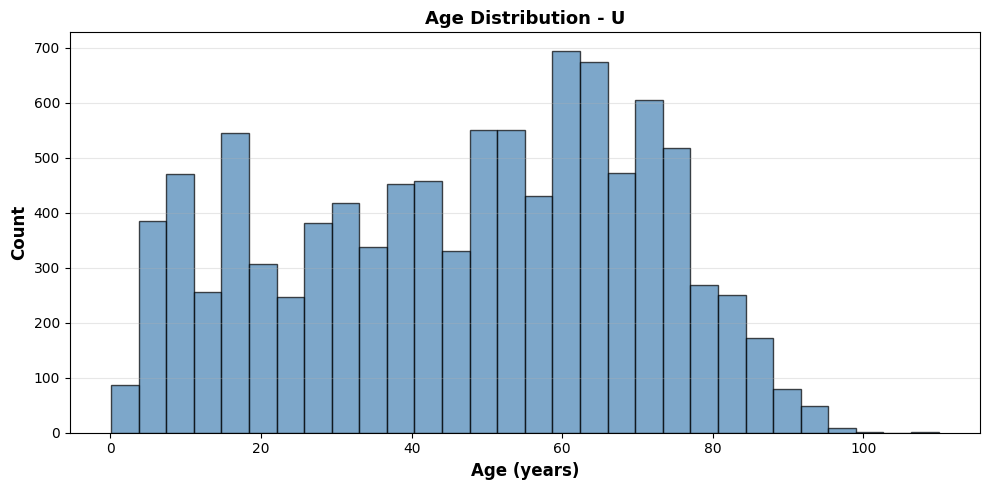

In [ ]:
# ============================================================
# 4.1 BASIC DESCRIPTIVE STATISTICS
# ============================================================

print("Case-level dataset shape:", df_clean.shape)
print("\nSerious rate:", df_clean["SERIOUS"].mean())

if "SEX" in df_clean.columns:
    print("\nSex distribution:")
    print(df_clean["SEX"].value_counts(dropna=False))

if "AGE_YRS" in df_clean.columns:
    print("\nAge summary:")
    print(df_clean["AGE_YRS"].describe())
    
    if "SEX" in df_clean.columns:
        for sex in df_clean["SEX"].unique():
            if pd.notna(sex):
                data = df_clean[df_clean["SEX"] == sex]["AGE_YRS"].dropna()
                
                plt.figure(figsize=(10, 5))
                plt.hist(data, bins=30, color="steelblue", edgecolor="black", alpha=0.7)
                plt.xlabel("Age (years)", fontsize=12, fontweight="bold")
                plt.ylabel("Count", fontsize=12, fontweight="bold")
                plt.title(f"Age Distribution - {sex}", fontsize=13, fontweight="bold")
                plt.grid(axis='y', alpha=0.3)
                plt.tight_layout()
                plt.show()

count    986096.000000
mean        726.199905
std        1038.736049
min           0.000000
25%         101.000000
50%         312.000000
75%        1051.000000
max       63998.000000
Name: SYMPTOM_TEXT_CHAR_LEN, dtype: float64


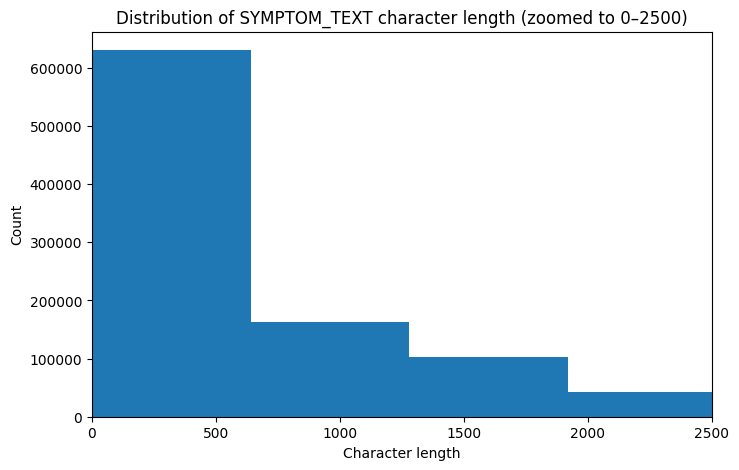

In [ ]:
# ============================================================
# 4.2 SYMPTOM NARRATIVE LENGTH
# ============================================================

if "SYMPTOM_TEXT" in df_clean.columns:
    df_clean["SYMPTOM_TEXT_CHAR_LEN"] = df_clean["SYMPTOM_TEXT"].fillna("").astype(str).str.len()
    print(df_clean["SYMPTOM_TEXT_CHAR_LEN"].describe())

    plt.figure(figsize=(8,5))
    plt.hist(df_clean["SYMPTOM_TEXT_CHAR_LEN"], bins=100)
    plt.xlim(0, 2500)
    plt.title("Distribution of SYMPTOM_TEXT character length (zoomed to 0-2500)")
    plt.xlabel("Character length")
    plt.ylabel("Count")
    plt.show()


TIME SERIES ANALYSIS: MONTHLY COVID REPORTS & SERIOUS OUTCOMES

15A. MONTHLY NUMBER OF COVID-19 REPORTS
--------------------------------------------------------------------------------

Date range: 2020-12-01 to 2025-07-01
Total months: 56
Total reports: 986,096

Monthly statistics:
  Mean:     17609 reports/month
  Median:   4396 reports/month
  Min:      262 (in July 2025)
  Max:      101,337 (in April 2021)

✓ Saved: /Users/ariellerothman/Desktop/Capstone/Outputs/01_monthly_report_count.png


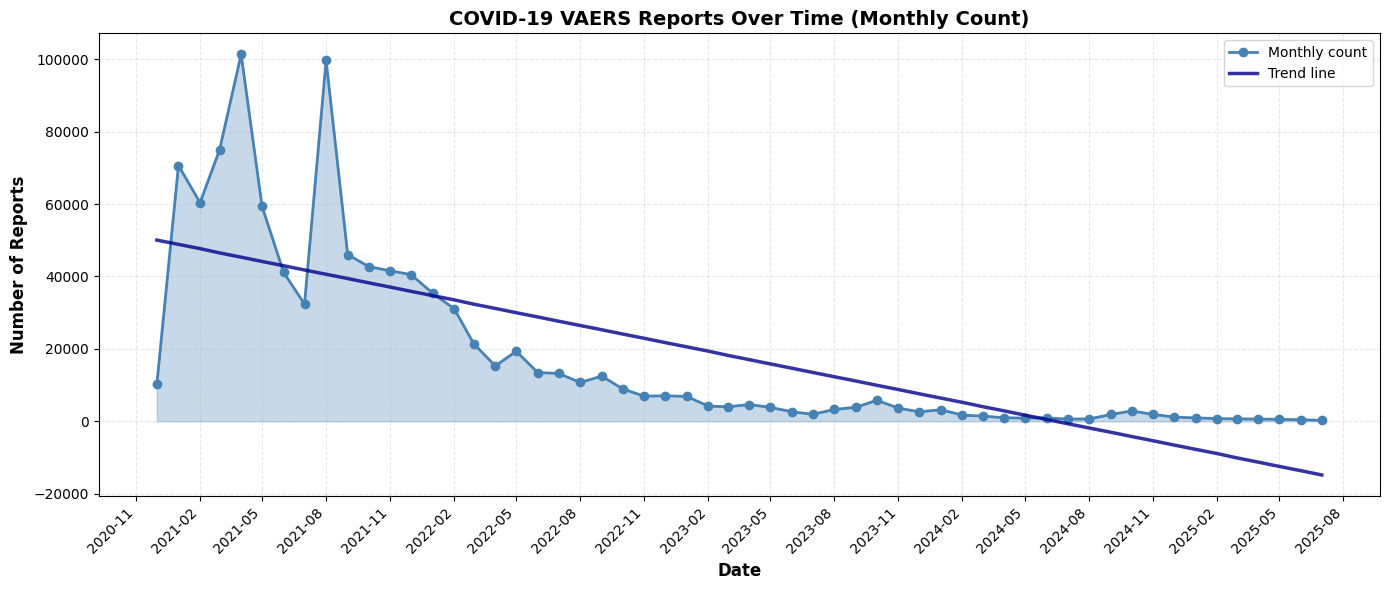

✓ Saved: /Users/ariellerothman/Desktop/Capstone/Outputs/monthly_report_count.csv


15B. MONTHLY PROPORTION OF SERIOUS REPORTS
--------------------------------------------------------------------------------

✓ Saved: /Users/ariellerothman/Desktop/Capstone/Outputs/02_monthly_serious_proportion.png


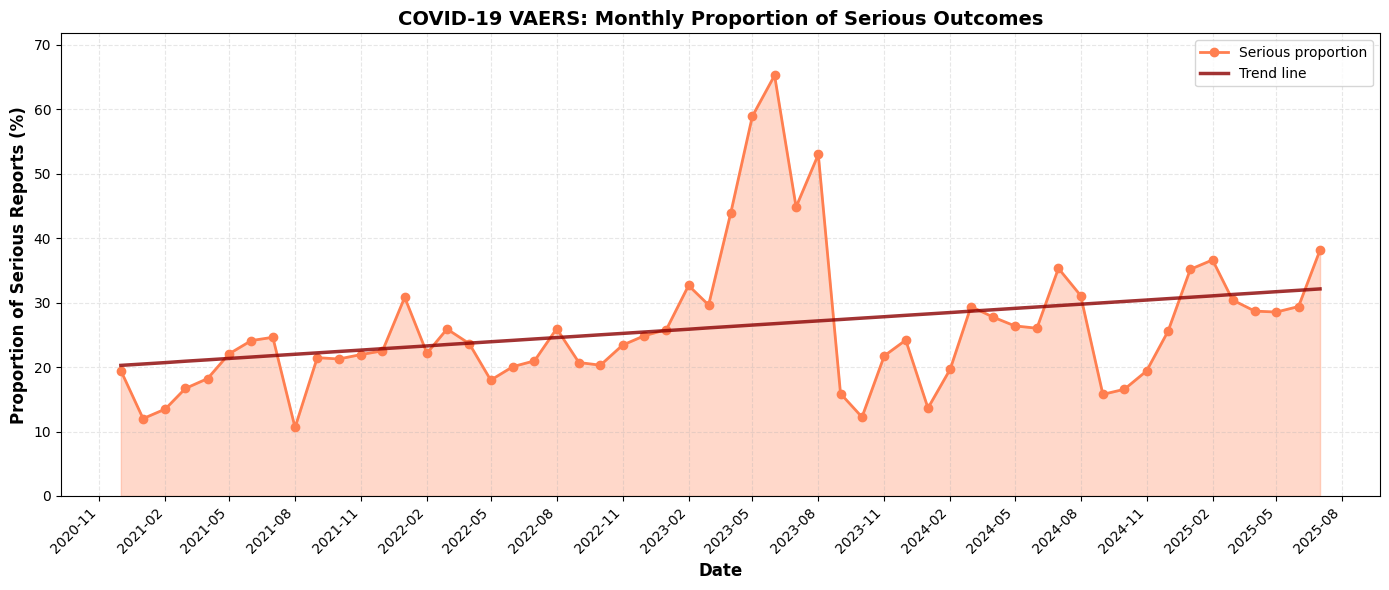

✓ Saved: /Users/ariellerothman/Desktop/Capstone/Outputs/monthly_serious_proportion.csv


15C. COMBINED TIME SERIES (Count + Serious Proportion)
--------------------------------------------------------------------------------

✓ Saved: /Users/ariellerothman/Desktop/Capstone/Outputs/03_combined_count_and_serious.png


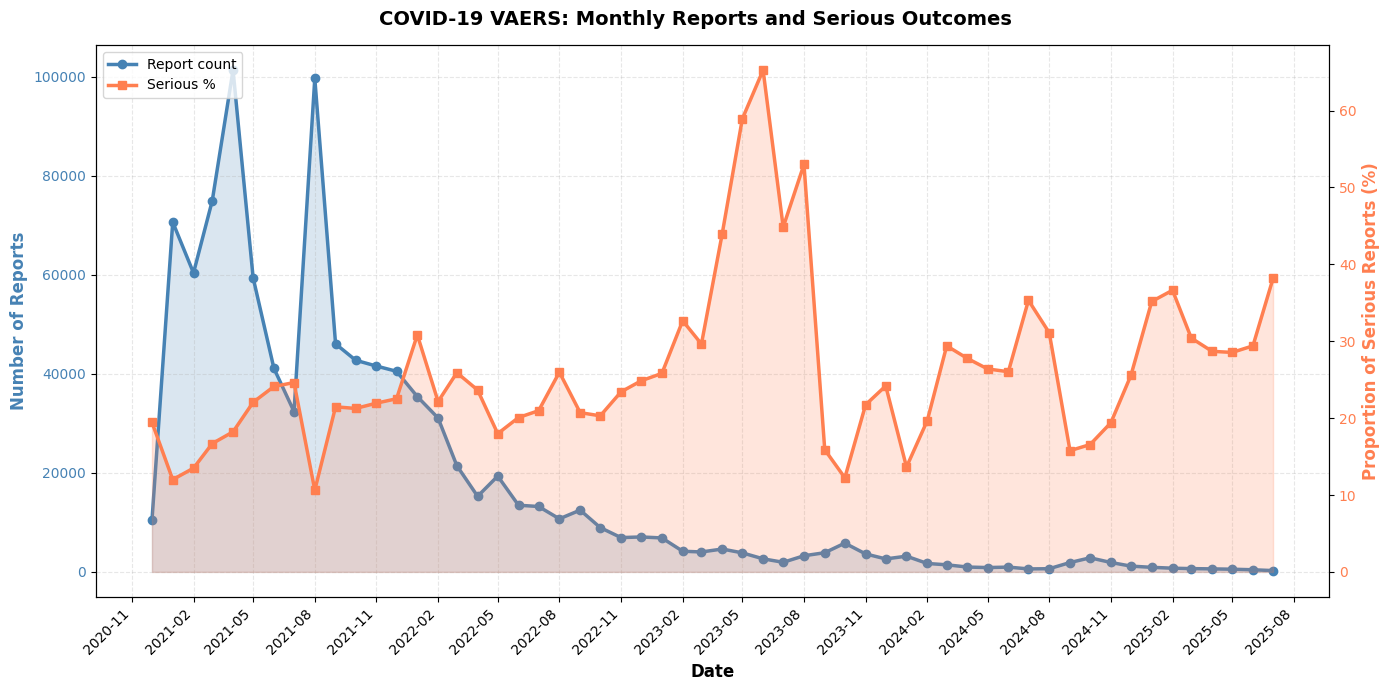



15D. YEARLY SUMMARY STATISTICS
--------------------------------------------------------------------------------

Yearly breakdown:
 year  total_reports  serious_count  serious_percent
 2020          10381           2020        19.458626
 2021         710732         126406        17.785326
 2022         195332          46477        23.793848
 2023          47292          15693        33.183202
 2024          18179           3793        20.864734
 2025           4180           1357        32.464115

✓ Saved: /Users/ariellerothman/Desktop/Capstone/Outputs/yearly_summary.csv


In [ ]:
# ============================================================
# 4.3 TIME SERIES ANALYSIS: MONTHLY COVID REPORTS & OUTCOMES
# ============================================================

print("\n" + "="*80)
print("TIME SERIES ANALYSIS: MONTHLY COVID REPORTS & SERIOUS OUTCOMES")
print("="*80)

if "RECVDATE" in df_clean.columns:
    df_clean["RECVDATE"] = pd.to_datetime(df_clean["RECVDATE"], errors="coerce")

if "YEAR" not in df_clean.columns:
    df_clean["YEAR"] = df_clean["RECVDATE"].dt.year
if "MONTH" not in df_clean.columns:
    df_clean["MONTH"] = df_clean["RECVDATE"].dt.month

df_clean["YEAR_MONTH"] = df_clean["RECVDATE"].dt.to_period("M")

print("\n4.3A. MONTHLY NUMBER OF COVID-19 REPORTS")
print("-" * 80)

monthly_counts = df_clean.groupby("YEAR_MONTH").size().reset_index(name="report_count")
monthly_counts["YEAR_MONTH"] = monthly_counts["YEAR_MONTH"].dt.to_timestamp()

print(f"\nDate range: {monthly_counts['YEAR_MONTH'].min().date()} to {monthly_counts['YEAR_MONTH'].max().date()}")
print(f"Total months: {len(monthly_counts)}")
print(f"Total reports: {monthly_counts['report_count'].sum():,}")
print(f"\nMonthly statistics:")
print(f"  Mean:     {monthly_counts['report_count'].mean():.0f} reports/month")
print(f"  Median:   {monthly_counts['report_count'].median():.0f} reports/month")
print(f"  Min:      {monthly_counts['report_count'].min():,} (in {monthly_counts.loc[monthly_counts['report_count'].idxmin(), 'YEAR_MONTH'].strftime('%B %Y')})")
print(f"  Max:      {monthly_counts['report_count'].max():,} (in {monthly_counts.loc[monthly_counts['report_count'].idxmax(), 'YEAR_MONTH'].strftime('%B %Y')})")

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_counts["YEAR_MONTH"], monthly_counts["report_count"], 
        marker="o", linewidth=2, markersize=6, color="steelblue", label="Monthly count")
ax.fill_between(monthly_counts["YEAR_MONTH"], monthly_counts["report_count"], 
                alpha=0.3, color="steelblue")

x_numeric = np.arange(len(monthly_counts))
z = np.polyfit(x_numeric, monthly_counts["report_count"], 1)
p = np.poly1d(z)
ax.plot(monthly_counts["YEAR_MONTH"], p(x_numeric), "darkblue", linewidth=2.5, 
        label="Trend line", alpha=0.8)

ax.set_xlabel("Date", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Reports", fontsize=12, fontweight="bold")
ax.set_title("COVID-19 VAERS Reports Over Time (Monthly Count)", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(fontsize=10)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(f"{OUTDIR}/01_monthly_report_count.png", dpi=300, bbox_inches="tight")
print(f"\nSaved: {OUTDIR}/01_monthly_report_count.png")
plt.show()

monthly_counts.to_csv(f"{OUTDIR}/monthly_report_count.csv", index=False)
print(f"Saved: {OUTDIR}/monthly_report_count.csv")

# MONTHLY SERIOUS OUTCOME PROPORTION
print("\n\n4.3B. MONTHLY PROPORTION OF SERIOUS REPORTS")
print("-" * 80)

if "SERIOUS" in df_clean.columns:
    monthly_serious = df_clean.groupby("YEAR_MONTH").agg(
        serious_count=("SERIOUS", "sum"),
        total=("SERIOUS", "count")
    ).reset_index()
    monthly_serious["serious_percent"] = monthly_serious["serious_count"] / monthly_serious["total"] * 100
    monthly_serious["YEAR_MONTH"] = monthly_serious["YEAR_MONTH"].dt.to_timestamp()

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(monthly_serious["YEAR_MONTH"], monthly_serious["serious_percent"],
            marker="o", linewidth=2, markersize=6, color="coral", label="Serious proportion")
    ax.fill_between(monthly_serious["YEAR_MONTH"], monthly_serious["serious_percent"],
                    alpha=0.3, color="coral")

    x_numeric = np.arange(len(monthly_serious))
    z = np.polyfit(x_numeric, monthly_serious["serious_percent"], 1)
    p = np.poly1d(z)
    ax.plot(monthly_serious["YEAR_MONTH"], p(x_numeric), "darkred", linewidth=2.5,
            label="Trend line", alpha=0.8)

    ax.set_xlabel("Date", fontsize=12, fontweight="bold")
    ax.set_ylabel("Proportion of Serious Reports (%)", fontsize=12, fontweight="bold")
    ax.set_title("COVID-19 VAERS: Monthly Proportion of Serious Outcomes", fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(fontsize=10)
    ax.set_ylim([0, monthly_serious["serious_percent"].max() * 1.1])

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/02_monthly_serious_proportion.png", dpi=300, bbox_inches="tight")
    print(f"\nSaved: {OUTDIR}/02_monthly_serious_proportion.png")
    plt.show()

    # Save to CSV
    monthly_serious.to_csv(f"{OUTDIR}/monthly_serious_proportion.csv", index=False)
    print(f"Saved: {OUTDIR}/monthly_serious_proportion.csv")

# COMBINED VIEW: COUNT + PROPORTION (DUAL AXIS)

print("\n\n4.3C. COMBINED TIME SERIES (Count + Serious Proportion)")
print("-" * 80)

if "SERIOUS" in df_clean.columns:
    fig, ax1 = plt.subplots(figsize=(14, 7))
    
    # Left axis: Report count
    color1 = "steelblue"
    ax1.set_xlabel("Date", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Number of Reports", fontsize=12, fontweight="bold", color=color1)
    ax1.plot(monthly_counts["YEAR_MONTH"], monthly_counts["report_count"], 
            marker="o", linewidth=2.5, markersize=6, color=color1, label="Report count", zorder=2)
    ax1.fill_between(monthly_counts["YEAR_MONTH"], monthly_counts["report_count"], 
                    alpha=0.2, color=color1)
    ax1.tick_params(axis="y", labelcolor=color1)
    ax1.grid(True, alpha=0.3, linestyle="--", zorder=1)
    
    # Right axis: Serious proportion
    ax2 = ax1.twinx()
    color2 = "coral"
    ax2.set_ylabel("Proportion of Serious Reports (%)", fontsize=12, fontweight="bold", color=color2)
    ax2.plot(monthly_serious["YEAR_MONTH"], monthly_serious["serious_percent"], 
            marker="s", linewidth=2.5, markersize=6, color=color2, label="Serious %", zorder=2)
    ax2.fill_between(monthly_serious["YEAR_MONTH"], monthly_serious["serious_percent"], 
                    alpha=0.2, color=color2)
    ax2.tick_params(axis="y", labelcolor=color2)
    
    # Title and formatting
    fig.suptitle("COVID-19 VAERS: Monthly Reports and Serious Outcomes", 
                fontsize=14, fontweight="bold", y=0.98)
    
    # Format x-axis
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
    
    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f"{OUTDIR}/03_combined_count_and_serious.png", dpi=300, bbox_inches="tight")
    print(f"\nSaved: {OUTDIR}/03_combined_count_and_serious.png")
    plt.show()

# YEARLY SUMMARY

print("\n\n4.3D. YEARLY SUMMARY STATISTICS")
print("-" * 80)

if "SERIOUS" in df_clean.columns:
    yearly_summary = df_clean.groupby("YEAR").agg({
        "VAERS_ID": "count",
        "SERIOUS": ["sum", "mean"]
    }).reset_index()
    
    yearly_summary.columns = ["year", "total_reports", "serious_count", "serious_rate"]
    yearly_summary["serious_percent"] = yearly_summary["serious_rate"] * 100
    yearly_summary = yearly_summary.sort_values("year")
    
    print("\nYearly breakdown:")
    print(yearly_summary[["year", "total_reports", "serious_count", "serious_percent"]].to_string(index=False))
    
    yearly_summary.to_csv(f"{OUTDIR}/yearly_summary.csv", index=False)
    print(f"\nSaved: {OUTDIR}/yearly_summary.csv")

## 5. Rule-based comorbidity indicators

This section converts selected free-text fields into structured binary indicators using field-specific keyword dictionaries.

In [ ]:
# ============================================================
# 5.1 RULE-BASED COMORBIDITY INDICATORS
# ============================================================
# Purpose: Convert free-text medical narratives into structured binary indicators
# Method: Field-specific regex pattern matching with null-token filtering
# Output: Binary columns like HISTORY__cardiovascular, CUR_ILL__diabetes, etc.


FREE_TEXT_FIELDS = ["HISTORY", "CUR_ILL", "ALLERGIES", "PRIOR_VAX", "LAB_DATA", "OTHER_MEDS"]

# Tokens considered "empty" or "no information" for each field
# Prevents false positives from phrases like "no known allergies"
NULL_TOKENS = {
    "none", "no", "n", "na", "n/a", "unknown", "unk", "none known", "not known",
    "nka", "nkda", "no known allergies", "no known drug allergies",
    "denies", "denies allergies", "no allergies", "nil", "negative"
}

# Compiled regex patterns for text cleaning
_keep = re.compile(r"[^a-z0-9\s\-\/]")        # Remove special characters
_ws = re.compile(r"\s+")                       # Collapse whitespace
_url = re.compile(r"http\S+|www\S+|https\S+") # Remove URLs
_email = re.compile(r"\S+@\S+")                # Remove email addresses

def normalize_text(x):
    """
    Normalize free-text medical field to lowercase, clean characters, and remove nulls.
    
    Args:
        x (str or NaN): Raw text from medical field.
    
    Returns:
        str: Cleaned, lowercased text. Empty string if null or contains only null tokens.
    
    Process:
        1. Convert to string and lowercase
        2. Remove URLs and email addresses (common in EMR exports)
        3. Keep only alphanumeric, spaces, hyphens, forward slashes
        4. Collapse multiple spaces
        5. Check final text against null token list
    
    Example:
        >>> normalize_text("HTN, CAD - no DM")
        'htn cad no dm'
        
        >>> normalize_text("No known allergies")
        ''  # Returns empty string (recognized as null token)
    """
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    if not x:
        return ""
    if x in NULL_TOKENS:
        return ""
    x = _url.sub(" ", x)
    x = _email.sub(" ", x)
    x = _keep.sub(" ", x)
    x = _ws.sub(" ", x).strip()
    if x in NULL_TOKENS:
        return ""
    return x

# Category-specific regex patterns for each text field
# Organized by: {FIELD: {CATEGORY: [patterns]}}
# Each pattern uses word boundaries (\b) to avoid substring matches
CATEGORY_MAP = {
    "CUR_ILL": {
        "acute_infection": [r"\bcovid\b", r"\bsars[-\s]?cov[-\s]?2\b", r"\binfluenza\b", r"\bflu\b", r"\binfection\b", r"\bpneumonia\b", r"\bbronchitis\b", r"\bviral\b", r"\bbacterial\b"],
        "chronic_cardiovascular": [r"\bhypertension\b", r"\bhtn\b", r"\bcad\b", r"\bcoronary\b", r"\bafib\b", r"\bheart failure\b", r"\bchf\b", r"\barrhythmia\b", r"\bmi\b", r"\bmyocardial infarction\b"],
        "chronic_respiratory": [r"\basthma\b", r"\bcopd\b", r"\bemphysema\b", r"\bchronic obstructive\b", r"\bsleep apnea\b", r"\bosa\b"],
        "metabolic_endocrine": [r"\bdiabetes\b", r"\bdm\b", r"\bdm2\b", r"\btype\s?2\b", r"\bobesity\b", r"\bhyperlipid\w*\b", r"\bdyslipid\w*\b"],
        "endocrine_thyroid": [r"\bthyroid\b", r"\bhypothyroid\w*\b", r"\bhyperthyroid\w*\b", r"\bhashimoto\w*\b", r"\bgraves\b"],
        "autoimmune_inflammatory": [r"\bautoimmune\b", r"\blupus\b", r"\bsle\b", r"\bra\b", r"\brheumatoid arthritis\b", r"\bmultiple sclerosis\b", r"\bms\b", r"\bibs\b", r"\bibd\b", r"\bceliac\b"],
        "neurologic": [r"\bseizure\b", r"\bepilepsy\b", r"\bstroke\b", r"\btia\b", r"\bparkinson\w*\b", r"\bneuropath\w*\b", r"\bdementia\b", r"\balzheimer\w*\b"],
        "neuro_headache": [r"\bmigraine\w*\b", r"\bheadache\w*\b", r"\bcluster headache\b"],
        "cancer_immunocompromised": [r"\bcancer\b", r"\bmalignan\w*\b", r"\bchemotherap\w*\b", r"\bradiation\b", r"\btransplant\b", r"\bhiv\b", r"\baids\b", r"\bimmunosupp\w*\b", r"\bimmunocompromis\w*\b"],
        "lymphatic_edema": [r"\blymph(edema|oedema)\b", r"\bedema\b", r"\bswelling\b"],
    },
    "HISTORY": {
        "cardiovascular": [r"\bhtn\b", r"\bhypertension\b", r"\bcad\b", r"\bcoronary\b", r"\bafib\b", r"\bheart failure\b", r"\bchf\b", r"\bmi\b", r"\bmyocardial infarction\b", r"\bvalve\b", r"\baortic stenosis\b"],
        "respiratory": [r"\basthma\b", r"\bcopd\b", r"\bemphysema\b", r"\bchronic obstructive\b", r"\bosa\b", r"\bsleep apnea\b"],
        "metabolic": [r"\bdiabetes\b", r"\bdm\b", r"\bdm2\b", r"\bobesity\b", r"\bhyperlipid\w*\b", r"\bdyslipid\w*\b"],
        "endocrine_thyroid": [r"\bthyroid\b", r"\bhypothyroid\w*\b", r"\bhyperthyroid\w*\b", r"\bhashimoto\w*\b", r"\bgraves\b"],
        "musculoskeletal": [r"\barthritis\b", r"\bosteoarthritis\b", r"\boa\b", r"\bgout\b", r"\bfibromyalgia\b", r"\bchronic pain\b"],
        "mental_health": [r"\bdepress\w*\b", r"\banxiety\b", r"\bptsd\b", r"\bbipolar\b", r"\bschizo\w*\b"],
        "gastrointestinal": [r"\bgerd\b", r"\bacid reflux\b", r"\bgastroesophageal\b", r"\bibs\b", r"\bconstipat\w*\b", r"\bdiverticul\w*\b"],
        "kidney": [r"\bckd\b", r"\bchronic kidney\b", r"\brenal\b", r"\bdialysis\b", r"\brenal failure\b", r"\bkidney transplant\b"],
        "clotting": [r"\bdvt\b", r"\bpe\b", r"\bthromb\w*\b", r"\bclot\b", r"\bembol\w*\b"],
        "autoimmune": [r"\bautoimmune\b", r"\blupus\b", r"\bsle\b", r"\bra\b", r"\bms\b", r"\bmultiple sclerosis\b"],
        "cancer_immunocompromised": [r"\bcancer\b", r"\bmalignan\w*\b", r"\bchemotherap\w*\b", r"\bradiation\b", r"\btransplant\b", r"\bhiv\b", r"\baids\b", r"\bimmunosupp\w*\b", r"\bimmunocompromis\w*\b"],
        "neurologic": [r"\bstroke\b", r"\btia\b", r"\bseizure\b", r"\bepilepsy\b", r"\bmigraine\w*\b", r"\bneuropath\w*\b", r"\bparkinson\w*\b"],
        "lymphatic_edema": [r"\blymph(edema|oedema)\b", r"\bedema\b"],
    },
    "ALLERGIES": {
        "drug_allergy": [r"\bpenicillin\b", r"\bsulfa\b", r"\bnsaid\b", r"\baspirin\b", r"\bceclor\b", r"\bkeflex\b", r"\bdoxycycline\b"],
        "food_allergy": [r"\bpeanut\b", r"\bnut\b", r"\begg\b", r"\bmilk\b", r"\bshellfish\b", r"\bgarlic\b"],
        "latex_other_contact": [r"\blatex\b", r"\bdetergent\b", r"\bfragrance\b"],
        "anaphylaxis_history": [r"\banaphylax\w*\b", r"\bepi[-\s]?pen\b", r"\bepinephrine\b"],
    },
    "PRIOR_VAX": {
        "prior_covid_vax": [r"\bcovid\b", r"\bpfizer\b", r"\bmoderna\b", r"\bjanssen\b", r"\bnovavax\b"],
        "prior_flu_vax": [r"\bflu\b", r"\binfluenza\b"],
        "prior_other_vax": [r"\bshingrix\b", r"\bshingles\b", r"\btetanus\b", r"\brabies\b", r"\bh1n1\b", r"\bmmr\b", r"\bhepatitis\b", r"\bvaricella\b"],
        "prior_vax_reaction": [r"\breaction\b", r"\ballergic\b", r"\banaphylax\w*\b", r"\bside effect\b", r"\bsyncope\b"],
    },
    "LAB_DATA": {
        "cardiac_markers": [r"\btroponin\b", r"\bbnp\b", r"\bck[-\s]?mb\b"],
        "coagulation": [r"\bd[-\s]?dimer\b", r"\binr\b", r"\bptt\b", r"\bfibrinogen\b"],
        "inflammation": [r"\bcrp\b", r"\besr\b", r"\bferritin\b"],
        "cbc": [r"\bwbc\b", r"\bplatelet\w*\b", r"\bhemoglobin\b", r"\bhgb\b"],
        "vitals_procedures": [r"\bbp\b", r"\bhr\b", r"\bspo2\b", r"\bultrasound\b", r"\bct\b", r"\bmri\b", r"\bx[-\s]?ray\b"],
    },
    "OTHER_MEDS": {
        "anticoagulant": [r"\bwarfarin\b", r"\bheparin\b", r"\beliquis\b", r"\bxarelto\b", r"\bapixaban\b", r"\brivaroxaban\b"],
        "statin": [r"\bstatin\b", r"\batorvastatin\b", r"\bsimvastatin\b", r"\brosuvastatin\b"],
        "immunosuppressant": [r"\bprednisone\b", r"\bsteroid\b", r"\bmethotrexate\b", r"\btacrolimus\b", r"\bcyclosporine\b"],
        "diabetes_meds": [r"\binsulin\b", r"\bmetformin\b", r"\bsemaglutide\b", r"\bozempic\b", r"\bglp[-\s]?1\b"],
        "thyroid_meds": [r"\blevothyroxine\b", r"\bsynthroid\b", r"\bliothyronine\b"],
        "psych_meds": [r"\bsertraline\b", r"\bfluoxetine\b", r"\bcitalopram\b", r"\bescitalopram\b", r"\bbuspirone\b", r"\balprazolam\b", r"\btrazodone\b"],
    },
}

def compile_map(category_map):
    """
    Precompile all regex patterns for efficient matching.
    
    Args:
        category_map (dict): Nested dict of {field: {category: [pattern_strings]}}.
    
    Returns:
        dict: Same structure with pattern_strings compiled to re.Pattern objects.
    
    Rationale: Compiling patterns once at setup is much faster than compiling
    during each row iteration when used in apply().
    
    Example:
        >>> compiled = compile_map(CATEGORY_MAP)
        >>> compiled["HISTORY"]["cardiovascular"][0]
        re.Pattern(r'\bhtn\b')
    """
    compiled = {}
    for col, cats in category_map.items():
        compiled[col] = {cat: [re.compile(p) for p in pats] for cat, pats in cats.items()}
    return compiled

COMPILED_MAP = compile_map(CATEGORY_MAP)

def flag_any(text, patterns):
    """
    Check if any regex pattern matches the text.
    
    Args:
        text (str): Normalized text to search.
        patterns (list of re.Pattern): Compiled regex patterns.
    
    Returns:
        int: 1 if any pattern matches, 0 otherwise. Used for binary indicator columns.
    
    Example:
        >>> patterns = [re.compile(r'\bdiabetes\b'), re.compile(r'\bdm\b')]
        >>> flag_any("patient has type 2 diabetes", patterns)
        1
        
        >>> flag_any("patient hypertensive", patterns)
        0
    """
    if not text:
        return 0
    return int(any(p.search(text) for p in patterns))

# Apply categorization to each text field
for col in FREE_TEXT_FIELDS:
    if col not in df_clean.columns:
        continue

    # Normalize the text field
    norm_col = f"{col}_NORM"
    df_clean[norm_col] = df_clean[col].apply(normalize_text)
    
    # Create missing flag (useful for imputation and model diagnostics)
    df_clean[f"{col}_MISSING"] = (df_clean[norm_col].str.len() == 0).astype("int8")

    # Apply category-specific rules if available
    if col in COMPILED_MAP:
        cat_cols = []
        for cat, pats in COMPILED_MAP[col].items():
            outcol = f"{col}__{cat}"
            df_clean[outcol] = df_clean[norm_col].apply(lambda t: flag_any(t, pats)).astype("int8")
            cat_cols.append(outcol)

        # Flag records with content that matched NO categories (OTHER bucket)
# Useful for quality control and identifying patterns we missed
        df_clean[f"{col}__other"] = (
            (df_clean[f"{col}_MISSING"] == 0) & (df_clean[cat_cols].sum(axis=1) == 0)
        ).astype("int8")

# Save engineered comorbidity features ONLY (exclude manufacturer one-hot columns)
engineered_cols = [
    c for c in df_clean.columns
    if (("__" in c and not c.startswith("MANU__")) or c.endswith("_MISSING"))
]

comorb_df = df_clean[["VAERS_ID"] + engineered_cols].copy()
comorb_csv_path = os.path.join(OUTDIR, "comorbidity_indicators.csv")
comorb_df.to_csv(comorb_csv_path, index=False)
print("Saved:", comorb_csv_path, "shape:", comorb_df.shape)

Saved: /Users/ariellerothman/Desktop/Capstone/Outputs/comorbidity_indicators.csv shape: (986096, 60)


In [ ]:
# ============================================================
# 5.2 COMORBIDITY DIAGNOSTICS
# ============================================================

from collections import defaultdict
import pandas as pd

print("=" * 80)
print("SIMPLIFIED COMORBIDITY DIAGNOSTICS")
print("=" * 80)

# A) List all binary indicators by source field 

categories = defaultdict(list)

for col in df_clean.columns:
    if "__" in col:
        field, category = col.split("__", 1)
        categories[field].append(category)

print("\nA) INDICATOR CATALOG")
for field in sorted(categories):
    print(f"\n{field}")
    print("-" * len(field))
    for c in sorted(categories[field]):
        print(c)


# B) Why manufacturer indicators show up

manu_cols = [c for c in df_clean.columns if c.startswith("MANU__")]
print("\nB) WHY MANUFACTURER SHOWS UP")
print(
    "Manufacturer appears because the filter '__' includes every double-underscore binary column, "
    "including one-hot manufacturer columns like MANU__PFIZER/BIONTECH."
)
print(f"Manufacturer indicator columns detected: {len(manu_cols)}")
if manu_cols:
    print("Examples:", manu_cols[:10])


# C) Explore indicator groups (example: HISTORY__kidney)

print("\nC) SAMPLE RECORDS FOR ONE INDICATOR")
example_indicator = "HISTORY__kidney"
if example_indicator in df_clean.columns and "HISTORY" in df_clean.columns:
    n = min(20, int((df_clean[example_indicator] == 1).sum()))
    if n > 0:
        display(df_clean.loc[df_clean[example_indicator] == 1, ["HISTORY"]].sample(n, random_state=42))
    else:
        print(f"No positive rows found for {example_indicator}.")
else:
    print(f"Column missing: {example_indicator} or HISTORY")


# D) Summary table for indicator prevalence 
print("\nD) INDICATOR PREVALENCE SUMMARY")
indicator_cols = [
    c for c in df_clean.columns
    if "__" in c and not c.startswith("MANU__")
]

summary = (
    df_clean[indicator_cols]
    .sum()
    .sort_values(ascending=False)
    .rename("count")
    .to_frame()
)

summary["percent"] = summary["count"] / len(df_clean) * 100

display(summary)

# Optional export
summary.to_csv(f"{OUTDIR}/simplified_indicator_summary.csv")
print(f"Saved: {OUTDIR}/simplified_indicator_summary.csv")

# -------------------------------------------------------------------
# E) Show examples for each FIELD__other bucket
# -------------------------------------------------------------------
print("\nE) FIELD__other EXAMPLES")

fields = ["HISTORY", "CUR_ILL", "ALLERGIES", "PRIOR_VAX", "LAB_DATA", "OTHER_MEDS"]

for field in fields:
    other_col = f"{field}__other"

    if other_col not in df_clean.columns or field not in df_clean.columns:
        continue

    candidates = df_clean.loc[df_clean[other_col] == 1, field].dropna()

    print("\n", field, "OTHER examples")

    if len(candidates) == 0:
        print("(none)")
        continue

    n = min(10, len(candidates))
    print(candidates.sample(n, random_state=42).to_string(index=False))

SIMPLIFIED COMORBIDITY DIAGNOSTICS

A) INDICATOR CATALOG

ALLERGIES
---------
anaphylaxis_history
drug_allergy
food_allergy
latex_other_contact
other

CUR_ILL
-------
acute_infection
autoimmune_inflammatory
cancer_immunocompromised
chronic_cardiovascular
chronic_respiratory
endocrine_thyroid
lymphatic_edema
metabolic_endocrine
neuro_headache
neurologic
other

HISTORY
-------
autoimmune
cancer_immunocompromised
cardiovascular
clotting
endocrine_thyroid
gastrointestinal
kidney
lymphatic_edema
mental_health
metabolic
musculoskeletal
neurologic
other
respiratory

LAB_DATA
--------
cardiac_markers
cbc
coagulation
inflammation
other
vitals_procedures

MANU
----
JANSSEN
MODERNA
NOVAVAX
PFIZER_BIONTECH
UNKNOWN_MANUFACTURER

OTHER_MEDS
----------
anticoagulant
diabetes_meds
immunosuppressant
other
psych_meds
statin
thyroid_meds

PRIOR_VAX
---------
other
prior_covid_vax
prior_flu_vax
prior_other_vax
prior_vax_reaction

B) WHY MANUFACTURER SHOWS UP
Manufacturer appears because the filter '__' in

,HISTORY
919812,"Asthma, UTIs, Medullary cystic kidney disease,..."
32019,Advanced dementia with severe violent behavior...
477431,Gastroesophageal reflux disease 03/16/2021 Unk...
593200,"Acidic stomach, Stage 3 CKD"
407837,"DIABETES MELLITUS, TYPE 2. CHRONIC KIDNEY DISE..."
912348,Cardiovascular Hypertension Paroxysmal atrial ...
607125,"Acid reflux, Arthritis, Eczema, Enlarged prost..."
571557,"Diabetes, Cardiovascular disease, Renal disease"
163048,Allergy induced asthma. Renal failure than ha...
321342,"lung disease, heart disease, renal disease"



D) INDICATOR PREVALENCE SUMMARY


,count,percent
OTHER_MEDS__other,271700,27.553098
LAB_DATA__other,195633,19.839143
HISTORY__other,172946,17.538455
ALLERGIES__other,143783,14.581035
ALLERGIES__drug_allergy,77583,7.867692
CUR_ILL__other,71218,7.222218
HISTORY__cardiovascular,63285,6.417732
HISTORY__respiratory,59886,6.073040
HISTORY__metabolic,56111,5.690217
LAB_DATA__vitals_procedures,53601,5.435678


Saved: /Users/ariellerothman/Desktop/Capstone/Outputs/simplified_indicator_summary.csv

E) FIELD__other EXAMPLES

 HISTORY OTHER examples
                            non hodgkins lymphonia
chronic gastritis, tachycardia, kidney stones. ...
Comments: List of non-encoded Patient Relevant ...
                                recurring shingles
                                      BMI elevated
Patient has idiopathic hives sometimes and also...
  Medical History/Concurrent Conditions: COVID-19.
Medical History/Concurrent Conditions: COVID-19...
Comments: No medical history was provided by th...
                      Barrett's esophagus syndrome

 CUR_ILL OTHER examples
                 period started day of vaccination
                      Anxiety; Blood pressure high
            Alcohol use (weekly maybe); Non-smoker
Bee sting hypersensitivity; Drug allergy (torad...
Allergy to vaccine; Drug allergy (NSAIDS); Drug...
         Sulfonamide allergy (Allergy sulfa drugs)
                     

In [ ]:
# ============================================================
# 5.3 IMPUTE MISSING VALUES FOR MODEL-READY EXPORT
# ============================================================

df_clean_imputed = df_clean.copy()

# Snapshot missingness before imputation
missing_before = int(df_clean_imputed.isna().sum().sum())
print(f"Total missing values BEFORE imputation: {missing_before:,}")

# 0) Enforce numeric dtypes for known numeric model fields
# This prevents string artifacts (e.g., "UNKNOWN") from polluting numeric columns.
expected_numeric_cols = [
    "AGE_YRS", "HOSPDAYS", "NUMDAYS", "ONSET_INTERVAL",
    "MAX_DOSE", "DOSE_COUNT", "MULTI_DOSE", "UNKNOWN_DOSE", "MULTI_MANUFACTURER",
    "YEAR", "MONTH", "SERIOUS", "SEVERE"
]
for col in expected_numeric_cols:
    if col in df_clean_imputed.columns:
        df_clean_imputed[col] = pd.to_numeric(df_clean_imputed[col], errors="coerce")

# 1) Binary indicators: fill with 0
binary_indicator_cols = [
    c for c in df_clean_imputed.columns
    if ("__" in c) or c.endswith("_MISSING")
]
for col in binary_indicator_cols:
    if col in df_clean_imputed.columns:
        df_clean_imputed[col] = pd.to_numeric(df_clean_imputed[col], errors="coerce").fillna(0).astype("int8")

# 2) Numeric features: median imputation (except VAERS_ID)
numeric_cols = df_clean_imputed.select_dtypes(include=["number"]).columns.tolist()
numeric_fill_cols = [c for c in numeric_cols if c not in binary_indicator_cols and c != "VAERS_ID"]
for col in numeric_fill_cols:
    if df_clean_imputed[col].isna().any():
        med = df_clean_imputed[col].median()
        if pd.isna(med):
            med = 0
        df_clean_imputed[col] = df_clean_imputed[col].fillna(med)

# 3) Free-text columns: empty string imputation
text_cols = [
    "SYMPTOM_TEXT", "LAB_DATA", "OTHER_MEDS", "CUR_ILL", "HISTORY", "PRIOR_VAX", "ALLERGIES",
    "HISTORY_NORM", "CUR_ILL_NORM", "ALLERGIES_NORM", "PRIOR_VAX_NORM", "LAB_DATA_NORM", "OTHER_MEDS_NORM"
]
for col in text_cols:
    if col in df_clean_imputed.columns:
        df_clean_imputed[col] = df_clean_imputed[col].fillna("")

# 4) Remaining object/string columns: 'UNKNOWN'
# (Only non-numeric-like columns should reach this step.)
obj_cols = df_clean_imputed.select_dtypes(include=["object", "string"]).columns.tolist()
for col in obj_cols:
    if col in text_cols:
        continue
    if df_clean_imputed[col].isna().any():
        df_clean_imputed[col] = df_clean_imputed[col].fillna("UNKNOWN")

missing_after = int(df_clean_imputed.isna().sum().sum())
print(f"Total missing values AFTER imputation:  {missing_after:,}")
print(f"Missing values reduced by:             {missing_before - missing_after:,}")
print(f"Imputed dataframe shape: {df_clean_imputed.shape}")

# Quick audit for remaining missingness
remaining_missing = (
    df_clean_imputed.isna().sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
)
if len(remaining_missing):
    print("\nRemaining missing values by column:")
    print(remaining_missing)
else:
    print("\nNo remaining missing values.")

Total missing values BEFORE imputation: 6,750,567
Total missing values AFTER imputation:  1,140,074
Missing values reduced by:             5,610,493
Imputed dataframe shape: (986096, 113)

Remaining missing values by column:
DATEDIED      968921
ONSET_DATE     97200
VAX_DATE       73953
dtype: int64


In [ ]:
# ============================================================
# 5.4 SAVE FINAL DATASETS (ENGINEERED + IMPUTED)
# ============================================================

# Save engineered dataset (pre-imputation snapshot)
engineered_csv_path = os.path.join(OUTDIR, "df_clean_engineered.csv")
df_clean.to_csv(engineered_csv_path, index=False)
print("Saved engineered dataset:", engineered_csv_path)
print("Engineered shape:", df_clean.shape)

# Save imputed dataset for downstream modeling notebooks
imputed_csv_path = os.path.join(OUTDIR, "df_clean_imputed.csv")
df_clean_imputed.to_csv(imputed_csv_path, index=False)
print("Saved imputed dataset:", imputed_csv_path)
print("Imputed shape:", df_clean_imputed.shape)

# Data dictionary for imputed export
data_dict = pd.DataFrame({
    "column": df_clean_imputed.columns,
    "dtype": df_clean_imputed.dtypes.astype(str),
    "non_null_count": df_clean_imputed.count(),
    "null_count": df_clean_imputed.isna().sum()
})
dict_path = os.path.join(OUTDIR, "data_dictionary.csv")
data_dict.to_csv(dict_path, index=False)
print("\nSaved data dictionary:", dict_path)

Saved engineered dataset: /Users/ariellerothman/Desktop/Capstone/Outputs/df_clean_engineered.csv
Engineered shape: (986096, 113)
Saved imputed dataset: /Users/ariellerothman/Desktop/Capstone/Outputs/df_clean_imputed.csv
Imputed shape: (986096, 113)

Saved data dictionary: /Users/ariellerothman/Desktop/Capstone/Outputs/data_dictionary.csv
